In [1]:
pip install pandas tqdm Pillow torchvision matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


# 영어 글리프 → 한글 글리프 English to Koean GAN

- ContentEncoder 입력을 **나눔고딕 고정 참조 이미지**로 고정
- 학습/추론 시 ContentEncoder 입력이 완전히 동일 → 도메인 갭 없음
- 나눔고딕 14자를 시작 전에 한 번만 렌더링해서 재사용

```
[학습/추론 동일]
나눔고딕 "가" 이미지 (고정)
      ↓
 ContentEncoder  →  구조 피처
      +
 StyleEncoder  ←  영어 글리프 16장
      ↓
 AdaIN → Generator  →  해당 폰트 스타일의 "가" 생성
```

In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
torch.backends.cudnn.benchmark = True


Device: cuda


In [3]:
# =========================
# 하이퍼파라미터
# =========================
CFG = {
    # 경로
    "manifest"      : "./gan_dataset/manifest.csv",
    "nanum_font"    : "./NanumGothic.ttf",   # ← 나눔고딕 경로
    "ckpt_dir"      : "./checkpoints",
    "sample_dir"    : "./samples",

    # 이미지
    "img_size"      : 128,
    "font_size_ref" : 110,    # 나눔고딕 렌더 폰트 크기
    "eng_sample_n"  : 16,

    # 모델
    "style_dim"     : 512,
    "n_kor_chars"   : 14,
    "char_emb_dim"  : 64,

    # 학습
    "batch_size"    : 32, #GPU NVIDIA 4070 기준 16 -> 32로 수정
    "lr_g"          : 2e-4,
    "lr_d"          : 2e-4,
    "n_epochs"      : 200,
    "save_every"    : 10,
    "sample_every"  : 5,

    # Loss 가중치
    "lambda_recon"  : 10.0,
    "lambda_perc"   : 1.0,
    "lambda_style"  : 50.0,

    "seed"          : 42,
}

KOR_CHARS = list("가나더려모부쇼야져쵸켜튜히")

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

Path(CFG["ckpt_dir"]).mkdir(parents=True, exist_ok=True)
Path(CFG["sample_dir"]).mkdir(parents=True, exist_ok=True)

나눔고딕 참조 이미지 준비 완료: torch.Size([13, 1, 128, 128])


C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 47140 (\N{HANGUL SYLLABLE RYEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\922373597.py:47: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s)

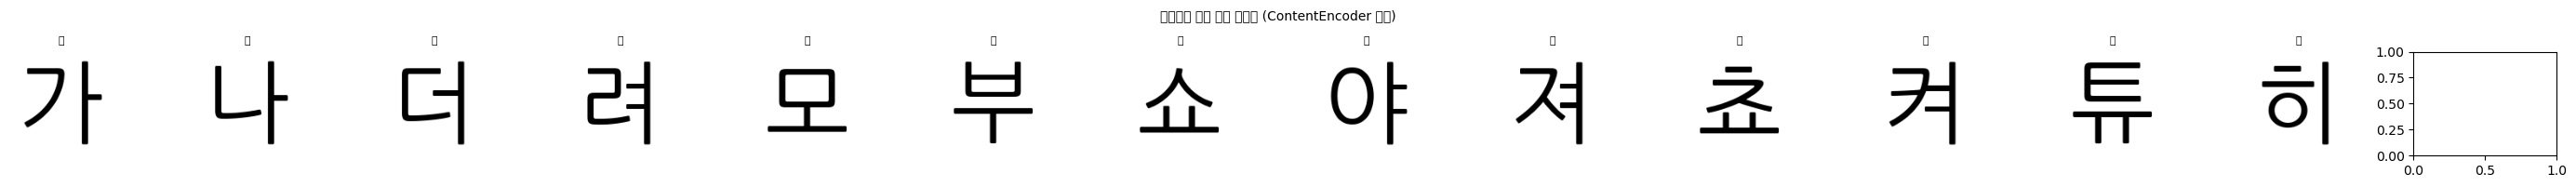

In [4]:
# =========================
# 나눔고딕 고정 참조 이미지 생성
# 딱 한 번만 렌더링 → 학습/추론 내내 재사용
# =========================

def render_ref_images(font_path, chars, img_size=128, font_size=110):
    """
    나눔고딕으로 14자를 렌더링해서
    텐서 (14, 1, 128, 128) 로 반환
    """
    tfm  = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
    font = ImageFont.truetype(str(font_path), size=font_size)
    imgs = []

    for ch in chars:
        img  = Image.new("L", (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = (img_size - w) // 2 - bbox[0]
        y = (img_size - h) // 2 - bbox[1]
        draw.text((x, y), ch, font=font, fill=0)
        imgs.append(tfm(img))

    return torch.stack(imgs)  # (14, 1, 128, 128)


# 고정 참조 이미지 (GPU로)
REF_IMGS = render_ref_images(
    CFG["nanum_font"], KOR_CHARS,
    img_size=CFG["img_size"],
    font_size=CFG["font_size_ref"]
).to(DEVICE)  # (14, 1, 128, 128)

print(f"나눔고딕 참조 이미지 준비 완료: {REF_IMGS.shape}")

# 확인용: 참조 이미지 미리보기
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 14, figsize=(28, 2))
for i, (ax, ch) in enumerate(zip(axes, KOR_CHARS)):
    img_np = ((REF_IMGS[i, 0].cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
    ax.imshow(img_np, cmap="gray")
    ax.set_title(ch, fontsize=8)
    ax.axis("off")
plt.suptitle("나눔고딕 고정 참조 이미지 (ContentEncoder 입력)", fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# =============================================================
# [STEP 1] manifest.csv 재생성 (WSL 경로로)
# - Windows 경로가 WSL에서 안 읽히므로 /mnt/c/... 경로로 새로 생성
# - 영어/한글 이미지가 16장 미만인 폰트는 제거 (학습 오류 방지)
# =============================================================
DATASET_ROOT = Path("./gan_dataset")

rows = []
for split in ["train", "val", "test"]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        print(f"폴더 없음: {split_dir}")
        continue
    for font_dir in sorted(split_dir.iterdir()):
        if not font_dir.is_dir():
            continue
        input_dir  = font_dir / "input"
        target_dir = font_dir / "target"
        # 폴더 자체가 없으면 스킵
        if not input_dir.exists() or not target_dir.exists():
            continue
        # 영어 이미지 16장 미만이면 스킵 (eng_sample_n=16 이므로)
        if len(list(input_dir.glob("*.png"))) < 16:
            continue
        # 한글 이미지 없으면 스킵
        if len(list(target_dir.glob("*.png"))) < 1:
            continue
        rows.append({
            "split"      : split,
            "font_id"    : font_dir.name,
            "input_dir"  : str(input_dir),
            "target_dir" : str(target_dir),
        })

df_manifest = pd.DataFrame(rows)
df_manifest.to_csv(CFG["manifest"], index=False)
print(f"manifest 재생성 완료: {len(df_manifest)}개 폰트")
print(df_manifest["split"].value_counts())

# =============================================================
# [STEP 2] GlyphDataset 클래스 정의
# - 폰트 수 × 14글자 = 전체 샘플 수
# - 매 호출마다 영어 글리프 16장 랜덤 샘플링 → StyleEncoder 입력
# - 정답 한글 이미지 로딩 → Generator 출력과 비교
# =============================================================
class GlyphDataset(Dataset):
    def __init__(self, manifest_path, split, eng_sample_n=16):
        df = pd.read_csv(manifest_path)
        self.rows         = df[df["split"] == split].reset_index(drop=True)
        self.eng_sample_n = eng_sample_n
        # Resize: 폰트마다 크기 다를 수 있어서 128×128 강제 통일
        # Normalize: [0,1] → [-1,1] (GAN 학습 안정화)
        self.tfm = T.Compose([
            T.Resize((128, 128)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        # 전체 샘플 수 = 폰트 수 × 14글자
        return len(self.rows) * 14

    def __getitem__(self, idx):
        font_idx = idx // 14   # 몇 번째 폰트인지
        char_idx = idx % 14    # 14글자 중 몇 번째인지 (0=가, 1=나 ...)
        row = self.rows.iloc[font_idx]

        # 영어 글리프: 매번 랜덤 16장 샘플링
        eng_files = list(Path(row["input_dir"]).glob("*.png"))
        sampled   = random.sample(eng_files, min(self.eng_sample_n, len(eng_files)))
        eng_imgs  = torch.stack(
            [self.tfm(Image.open(f).convert("L")) for f in sampled]
        )  # (16, 1, 128, 128)

        # 정답 한글 글리프
        kor_files = sorted(Path(row["target_dir"]).glob("*.png"))
        char_idx  = min(char_idx, len(kor_files) - 1)
        kor_img   = self.tfm(Image.open(kor_files[char_idx]).convert("L"))

        return {
            "eng_imgs" : eng_imgs,
            "kor_img"  : kor_img,
            "char_idx" : torch.tensor(char_idx, dtype=torch.long),
        }

# =============================================================
# [STEP 3] Dataset & DataLoader 생성
# - num_workers=4: WSL(Linux)이라 멀티프로세싱 정상 동작
# - persistent_workers: 에폭마다 워커 재시작 오버헤드 제거
# =============================================================
train_ds = GlyphDataset(CFG["manifest"], "train", eng_sample_n=CFG["eng_sample_n"])
val_ds   = GlyphDataset(CFG["manifest"], "val",   eng_sample_n=CFG["eng_sample_n"])

train_loader = DataLoader(
    train_ds,
    batch_size         = CFG["batch_size"],
    shuffle            = True,
    num_workers        = 0, #우선 멀리프로세싱의 문제인지 보기 위해서 0으로 수정
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = 2
)
val_loader = DataLoader(
    val_ds,
    batch_size         = CFG["batch_size"],
    shuffle            = False,
    num_workers        = 2,
    pin_memory         = True,
    persistent_workers = True,
    prefetch_factor    = 2
)

print(f"Train: {len(train_ds):,} samples ({len(train_loader)} batches)")
print(f"Val  : {len(val_ds):,} samples ({len(val_loader)} batches)")

manifest 재생성 완료: 346개 폰트
split
train    277
test      57
val       12
Name: count, dtype: int64


ValueError: prefetch_factor option could only be specified in multiprocessing.let num_workers > 0 to enable multiprocessing, otherwise set prefetch_factor to None.

In [22]:
# =========================
# 모델 블록
# =========================

class AdaIN(nn.Module):
    def __init__(self, feat_dim, style_dim):
        super().__init__()
        self.norm  = nn.InstanceNorm2d(feat_dim, affine=False)
        self.gamma = nn.Linear(style_dim, feat_dim)
        self.beta  = nn.Linear(style_dim, feat_dim)

    def forward(self, x, s):
        g = self.gamma(s).unsqueeze(-1).unsqueeze(-1)
        b = self.beta(s).unsqueeze(-1).unsqueeze(-1)
        return g * self.norm(x) + b


class ResBlockAdaIN(nn.Module):
    def __init__(self, channels, style_dim):
        super().__init__()
        self.conv1  = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.conv2  = nn.Conv2d(channels, channels, 3, 1, 1, bias=False)
        self.adain1 = AdaIN(channels, style_dim)
        self.adain2 = AdaIN(channels, style_dim)

    def forward(self, x, s):
        r = F.relu(self.adain1(self.conv1(x), s))
        r = self.adain2(self.conv2(r), s)
        return F.relu(x + r)


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 4, stride, 1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

In [23]:
# =========================
# StyleEncoder
# =========================
class StyleEncoder(nn.Module):
    """
    영어 글리프 N장 → 스타일 벡터 s
    입력: (B, N, 1, 128, 128)
    출력: (B, style_dim)
    """
    def __init__(self, style_dim=512):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1,   64,  stride=2),  # 128→64
            ConvBlock(64,  128, stride=2),  # 64→32
            ConvBlock(128, 256, stride=2),  # 32→16
            ConvBlock(256, 512, stride=2),  # 16→8
            ConvBlock(512, 512, stride=2),  # 8→4
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(512, style_dim)

    def forward(self, imgs):
        B, N, C, H, W = imgs.shape
        x = imgs.view(B * N, C, H, W)
        x = self.encoder(x).view(B, N, 512)
        x = x.mean(dim=1)          # N장 평균
        return self.fc(x)           # (B, style_dim)


# =========================
# ContentEncoder
# =========================
class ContentEncoder(nn.Module):
    """
    나눔고딕 고정 참조 이미지 + 글자 ID → 구조 피처

    ★ 핵심: 입력이 항상 나눔고딕 이미지로 고정이므로
       학습과 추론에서 완전히 동일한 구조 피처가 나옴

    입력: ref_img (B, 1, 128, 128), char_idx (B,)
    출력: (B, 256, 16, 16)
    """
    def __init__(self, n_chars=14, char_emb_dim=64):
        super().__init__()
        self.img_enc = nn.Sequential(
            ConvBlock(1,   64,  stride=2),  # 128→64
            ConvBlock(64,  128, stride=2),  # 64→32
            ConvBlock(128, 192, stride=2),  # 32→16
        )
        self.char_emb = nn.Embedding(n_chars, char_emb_dim)
        self.proj = nn.Conv2d(192 + char_emb_dim, 256, 1)

    def forward(self, ref_img, char_idx):
        feat = self.img_enc(ref_img)                             # (B, 192, 16, 16)
        emb  = self.char_emb(char_idx)                          # (B, char_emb_dim)
        emb  = emb.unsqueeze(-1).unsqueeze(-1)                  # (B, emb, 1, 1)
        emb  = emb.expand(-1, -1, feat.shape[2], feat.shape[3]) # (B, emb, 16, 16)
        x    = torch.cat([feat, emb], dim=1)
        return self.proj(x)                                      # (B, 256, 16, 16)


# =========================
# Generator
# =========================
class Generator(nn.Module):
    """
    구조 피처 + 스타일 벡터 → 한글 글리프
    입력: content (B, 256, 16, 16), style (B, style_dim)
    출력: (B, 1, 128, 128)
    """
    def __init__(self, style_dim=512):
        super().__init__()
        self.res_blocks = nn.ModuleList([
            ResBlockAdaIN(256, style_dim) for _ in range(4)
        ])
        self.up1   = UpBlock(256, 128)  # 16→32
        self.up2   = UpBlock(128, 64)   # 32→64
        self.up3   = UpBlock(64,  32)   # 64→128
        self.final = nn.Sequential(
            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, content, style):
        x = content
        for res in self.res_blocks:
            x = res(x, style)
        return self.final(self.up3(self.up2(self.up1(x))))


# =========================
# Discriminator (PatchGAN)
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            ConvBlock(64,  128, stride=2),
            ConvBlock(128, 256, stride=2),
            ConvBlock(256, 512, stride=1),
            nn.Conv2d(512, 1, 4, 1, 1),
        )
    def forward(self, x):
        return self.net(x)
    

In [24]:
# =========================
# Loss
# =========================

def hinge_d_loss(real_pred, fake_pred):
    return F.relu(1.0 - real_pred).mean() + F.relu(1.0 + fake_pred).mean()

def hinge_g_loss(fake_pred):
    return -fake_pred.mean()


class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.slice1 = nn.Sequential(*list(vgg)[:4]).eval()
        self.slice2 = nn.Sequential(*list(vgg)[4:9]).eval()
        self.slice3 = nn.Sequential(*list(vgg)[9:16]).eval()
        for p in self.parameters():
            p.requires_grad = False

    def get_features(self, x):
        x  = x.repeat(1, 3, 1, 1)  # 그레이 → 3채널
        f1 = self.slice1(x)
        f2 = self.slice2(f1)
        f3 = self.slice3(f2)
        return [f1, f2, f3]

    @staticmethod
    def gram(feat):
        B, C, H, W = feat.shape
        f = feat.view(B, C, H * W)
        return torch.bmm(f, f.transpose(1, 2)) / (C * H * W)

    def forward(self, pred, target):
        pf = self.get_features(pred)
        tf = self.get_features(target)
        perc  = sum(F.l1_loss(p, t) for p, t in zip(pf, tf))
        style = sum(F.l1_loss(self.gram(p), self.gram(t)) for p, t in zip(pf, tf))
        return perc, style

In [25]:
# =========================
# 초기화
# =========================
style_enc    = StyleEncoder(style_dim=CFG["style_dim"]).to(DEVICE)
content_enc  = ContentEncoder(n_chars=CFG["n_kor_chars"],
                               char_emb_dim=CFG["char_emb_dim"]).to(DEVICE)
generator    = Generator(style_dim=CFG["style_dim"]).to(DEVICE)
discriminator = Discriminator().to(DEVICE)
vgg_loss     = VGGPerceptualLoss().to(DEVICE)

g_params = (list(style_enc.parameters()) +
             list(content_enc.parameters()) +
             list(generator.parameters()))

opt_g = torch.optim.Adam(g_params,                  lr=CFG["lr_g"], betas=(0.5, 0.999))
opt_d = torch.optim.Adam(discriminator.parameters(), lr=CFG["lr_d"], betas=(0.5, 0.999))

def lr_lambda(epoch):
    decay = CFG["n_epochs"] // 2
    return 1.0 if epoch < decay else 1.0 - (epoch - decay) / (CFG["n_epochs"] - decay)

sched_g = torch.optim.lr_scheduler.LambdaLR(opt_g, lr_lambda)
sched_d = torch.optim.lr_scheduler.LambdaLR(opt_d, lr_lambda)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"StyleEncoder  : {count_params(style_enc):,}")
print(f"ContentEncoder: {count_params(content_enc):,}")
print(f"Generator     : {count_params(generator):,}")
print(f"Discriminator : {count_params(discriminator):,}")
# ── torch.compile (WSL 환경에서는 nvcc 권한 문제로 비활성화) ──
# style_enc     = torch.compile(style_enc)
# content_enc   = torch.compile(content_enc)
# generator     = torch.compile(generator)
# discriminator = torch.compile(discriminator)


StyleEncoder  : 7,210,496
ContentEncoder: 592,000
Generator     : 7,207,201
Discriminator : 2,761,793


In [26]:
# =========================
# 학습 루프
# =========================

def forward_G(batch):
    """
    Generator 순전파
    - 영어 글리프 → StyleEncoder → 스타일 벡터
    - 나눔고딕 참조 이미지 → ContentEncoder → 구조 피처
    - 스타일 + 구조 → Generator → 한글 글리프 생성
    """
    eng_imgs = batch["eng_imgs"].to(DEVICE)   # (B, 16, 1, 128, 128)
    kor_img  = batch["kor_img"].to(DEVICE)    # (B, 1, 128, 128) ← 정답
    char_idx = batch["char_idx"].to(DEVICE)   # (B,)

    # 나눔고딕 참조 이미지를 char_idx로 인덱싱 (고정 참조)
    ref_img = REF_IMGS[char_idx]              # (B, 1, 128, 128)

    style   = style_enc(eng_imgs)             # (B, style_dim)
    content = content_enc(ref_img, char_idx)  # (B, 256, 16, 16)
    fake    = generator(content, style)       # (B, 1, 128, 128)

    return fake, kor_img


def save_samples(epoch):
    """5 에폭마다 샘플 이미지 저장 (좌: 정답 / 우: 생성)"""
    style_enc.eval(); content_enc.eval(); generator.eval()
    with torch.no_grad():
        batch = next(iter(val_loader))
        fake, real = forward_G(batch)
        real_np = ((real[0, 0].cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
        fake_np = ((fake[0, 0].cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
        Image.fromarray(np.hstack([real_np, fake_np])).save(
            f"{CFG['sample_dir']}/epoch_{epoch:04d}.png")
    style_enc.train(); content_enc.train(); generator.train()


history = []

from torch.cuda.amp import autocast, GradScaler
scaler_g = GradScaler()
scaler_d = GradScaler()

for epoch in range(1, CFG["n_epochs"] + 1):
    d_sum = g_sum = 0.0  # ← 버그 수정: 루프 안으로 이동

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{CFG['n_epochs']}"):
        real_img = batch["kor_img"].to(DEVICE)

        # ── D 업데이트 ──────────────────────────────────────────
        # Discriminator가 진짜/가짜를 더 잘 구별하도록 학습
        with autocast():
            fake_img, _ = forward_G(batch)
            loss_d = hinge_d_loss(discriminator(real_img),
                                  discriminator(fake_img.detach()))
        opt_d.zero_grad()
        scaler_d.scale(loss_d).backward()
        scaler_d.step(opt_d)
        scaler_d.update()

        # ── G 업데이트 ──────────────────────────────────────────
        # Generator가 Discriminator를 속이면서 정답과 유사한 이미지 생성
        with autocast():
            fake_img, real_img_g = forward_G(batch)
            loss_adv             = hinge_g_loss(discriminator(fake_img))
            loss_recon           = F.l1_loss(fake_img, real_img_g)
            loss_perc, loss_sty  = vgg_loss(fake_img, real_img_g)
            loss_g = (loss_adv
                      + CFG["lambda_recon"] * loss_recon
                      + CFG["lambda_perc"]  * loss_perc
                      + CFG["lambda_style"] * loss_sty)
        opt_g.zero_grad()
        scaler_g.scale(loss_g).backward()
        scaler_g.step(opt_g)
        scaler_g.update()

        d_sum += loss_d.item()
        g_sum += loss_g.item()

    # 에폭 끝: 스케줄러 업데이트 + 로그 출력
    sched_g.step(); sched_d.step()

    n = len(train_loader)
    history.append({"epoch": epoch, "loss_d": d_sum/n, "loss_g": g_sum/n})
    print(f"Epoch {epoch:03d} | D: {d_sum/n:.4f}  G: {g_sum/n:.4f}")

    # 5 에폭마다 샘플 이미지 저장
    if epoch % CFG["sample_every"] == 0:
        save_samples(epoch)

    # 10 에폭마다 체크포인트 저장
    if epoch % CFG["save_every"] == 0:
        torch.save({
            "epoch"        : epoch,
            "style_enc"    : style_enc.state_dict(),
            "content_enc"  : content_enc.state_dict(),
            "generator"    : generator.state_dict(),
            "discriminator": discriminator.state_dict(),
            "opt_g"        : opt_g.state_dict(),
            "opt_d"        : opt_d.state_dict(),
        }, f"{CFG['ckpt_dir']}/epoch_{epoch:04d}.pt")
        print(f"  ✓ checkpoint saved → epoch_{epoch:04d}.pt")

print("\n학습 완료!")

C:\Users\only\AppData\Local\Temp\ipykernel_361968\2653972288.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_g = GradScaler()
C:\Users\only\AppData\Local\Temp\ipykernel_361968\2653972288.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_d = GradScaler()
Epoch 1/200:   0%|                                                                             | 0/122 [00:05<?, ?it/s]


RuntimeError: DataLoader worker (pid(s) 407988, 401056, 407388, 410176) exited unexpectedly

In [ ]:
# DataLoader는 위 셀(Dataset 셀)에 포함되어 있습니다.
# 이 셀은 실행 불필요


In [ ]:
# =========================
# 추론: 새 폰트 → 14자 생성
# =========================
def generate_14_chars(ckpt_path, font_input_dir, out_dir="./output_14"):
    """
    새 폰트의 영어 글리프 폴더를 받아서 한글 14자 생성

    Args:
        ckpt_path      : 체크포인트 .pt 경로
        font_input_dir : 새 폰트의 input/ 폴더 (영어 .png들)
        out_dir        : 결과 저장 폴더
    """
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    style_enc.load_state_dict(ckpt["style_enc"])
    content_enc.load_state_dict(ckpt["content_enc"])
    generator.load_state_dict(ckpt["generator"])
    style_enc.eval(); content_enc.eval(); generator.eval()

    tfm = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    # 영어 16장 랜덤 샘플 → 스타일 벡터
    eng_files = list(Path(font_input_dir).glob("*.png"))
    sampled   = random.sample(eng_files, min(CFG["eng_sample_n"], len(eng_files)))
    eng_imgs  = torch.stack([tfm(Image.open(f).convert("L")) for f in sampled])
    eng_imgs  = eng_imgs.unsqueeze(0).to(DEVICE)  # (1, 16, 1, 128, 128)

    with torch.no_grad():
        style = style_enc(eng_imgs)               # (1, style_dim)

        for i, ch in enumerate(KOR_CHARS):
            # ★ 추론도 나눔고딕 참조 그대로 사용 → 학습과 완전 동일
            ref_img  = REF_IMGS[i].unsqueeze(0)   # (1, 1, 128, 128)
            char_idx = torch.tensor([i]).to(DEVICE)
            content  = content_enc(ref_img, char_idx)
            fake     = generator(content, style)

            out_np = ((fake[0, 0].cpu().numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            Image.fromarray(out_np).save(f"{out_dir}/{ch}.png")
            print(f"  생성: {ch}.png")

    print(f"\n14자 생성 완료 → {out_dir}")


# 사용 예시:
# generate_14_chars(
#     ckpt_path      = "./checkpoints/epoch_0200.pt",
#     font_input_dir = "./gan_dataset/test/some_font_id/input",
#     out_dir        = "./output_14"
# )

In [ ]:
import pandas as pd

df = pd.read_csv("./gan_dataset/manifest.csv")
val_df = df[df["split"] == "val"].reset_index(drop=True)

# val DataLoader 첫 번째 폰트
print(val_df.iloc[0]["font_file"])   # ← 실제 폰트 파일 경로
print(val_df.iloc[0]["font_id"])     # ← 폰트 ID

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

def render_new_font_glyphs(font_path, out_dir, img_size=128, font_size=100):
    """
    새 폰트 .ttf → 영어 글리프 이미지 폴더 생성
    """
    ENG_POOL = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")
    out_dir  = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    font = ImageFont.truetype(str(font_path), size=font_size)
    
    for ch in ENG_POOL:
        img  = Image.new("L", (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = (img_size - w) // 2 - bbox[0]
        y = (img_size - h) // 2 - bbox[1]
        draw.text((x, y), ch, font=font, fill=0)
        
        fname = f"lower_{ch}.png" if ch.islower() else f"{ch}.png"
        img.save(out_dir / fname)
    
    print(f"영어 글리프 {len(ENG_POOL)}장 저장 완료 → {out_dir}")

# 실행
render_new_font_glyphs(
    font_path = r".\english_only_google_fonts\aboreto\Aboreto-Regular.ttf",
    out_dir   = "./new_font_test/aboreto/input"
)

In [ ]:
generate_14_chars(
    ckpt_path      = "./checkpoints/epoch_0200.pt",
    font_input_dir = "./new_font_test/aboreto/input",
    out_dir        = "./new_font_test/aboreto/output"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, (ax, ch) in enumerate(zip(axes.flatten(), KOR_CHARS)):
    img = mpimg.imread(f"./new_font_test/aboreto/output/{ch}.png")
    ax.imshow(img, cmap="gray")
    ax.set_title(ch, fontsize=14)
    ax.axis("off")
plt.suptitle("Aboreto 스타일 한글 14자", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

def render_new_font_glyphs(font_path, out_dir, img_size=128, font_size=100):
    """
    새 폰트 .ttf → 영어 글리프 이미지 폴더 생성
    """
    ENG_POOL = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")
    out_dir  = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    font = ImageFont.truetype(str(font_path), size=font_size)
    
    for ch in ENG_POOL:
        img  = Image.new("L", (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = (img_size - w) // 2 - bbox[0]
        y = (img_size - h) // 2 - bbox[1]
        draw.text((x, y), ch, font=font, fill=0)
        
        fname = f"lower_{ch}.png" if ch.islower() else f"{ch}.png"
        img.save(out_dir / fname)
    
    print(f"영어 글리프 {len(ENG_POOL)}장 저장 완료 → {out_dir}")

# 실행
render_new_font_glyphs(
    font_path = r".\english_only_google_fonts\abrilfatface\AbrilFatface-Regular.ttf",
    out_dir   = "./new_font_test/abrilfatface/input"
)

In [ ]:
generate_14_chars(
    ckpt_path      = "./checkpoints/epoch_0200.pt",
    font_input_dir = "./new_font_test/abrilfatface/input",
    out_dir        = "./new_font_test/abrilfatface/output"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, (ax, ch) in enumerate(zip(axes.flatten(), KOR_CHARS)):
    img = mpimg.imread(f"./new_font_test/abrilfatface/output/{ch}.png")
    ax.imshow(img, cmap="gray")
    ax.set_title(ch, fontsize=14)
    ax.axis("off")
plt.suptitle("Aboreto 스타일 한글 14자", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

def render_new_font_glyphs(font_path, out_dir, img_size=128, font_size=100):
    """
    새 폰트 .ttf → 영어 글리프 이미지 폴더 생성
    """
    ENG_POOL = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")
    out_dir  = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    font = ImageFont.truetype(str(font_path), size=font_size)
    
    for ch in ENG_POOL:
        img  = Image.new("L", (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = (img_size - w) // 2 - bbox[0]
        y = (img_size - h) // 2 - bbox[1]
        draw.text((x, y), ch, font=font, fill=0)
        
        fname = f"lower_{ch}.png" if ch.islower() else f"{ch}.png"
        img.save(out_dir / fname)
    
    print(f"영어 글리프 {len(ENG_POOL)}장 저장 완료 → {out_dir}")

# 실행
render_new_font_glyphs(
    font_path = r".\english_only_google_fonts\aclonica\Aclonica-Regular.ttf",
    out_dir   = "./new_font_test/aclonica/input"
)

In [ ]:
generate_14_chars(
    ckpt_path      = "./checkpoints/epoch_0200.pt",
    font_input_dir = "./new_font_test/aclonica/input",
    out_dir        = "./new_font_test/aclonica/output"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, (ax, ch) in enumerate(zip(axes.flatten(), KOR_CHARS)):
    img = mpimg.imread(f"./new_font_test/Aclonica/output/{ch}.png")
    ax.imshow(img, cmap="gray")
    ax.set_title(ch, fontsize=14)
    ax.axis("off")
plt.suptitle("aclonica 스타일 한글 14자", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

def render_new_font_glyphs(font_path, out_dir, img_size=128, font_size=100):
    """
    새 폰트 .ttf → 영어 글리프 이미지 폴더 생성
    """
    ENG_POOL = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")
    out_dir  = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    font = ImageFont.truetype(str(font_path), size=font_size)
    
    for ch in ENG_POOL:
        img  = Image.new("L", (img_size, img_size), color=255)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), ch, font=font)
        w = bbox[2] - bbox[0]
        h = bbox[3] - bbox[1]
        x = (img_size - w) // 2 - bbox[0]
        y = (img_size - h) // 2 - bbox[1]
        draw.text((x, y), ch, font=font, fill=0)
        
        fname = f"lower_{ch}.png" if ch.islower() else f"{ch}.png"
        img.save(out_dir / fname)
    
    print(f"영어 글리프 {len(ENG_POOL)}장 저장 완료 → {out_dir}")

# 실행
render_new_font_glyphs(
    font_path = r".\english_only_google_fonts\alkatra\Alkatra[wght].ttf",
    out_dir   = "./new_font_test/alkatra/input"
)

In [ ]:
generate_14_chars(
    ckpt_path      = "./checkpoints/epoch_0200.pt",
    font_input_dir = "./new_font_test/alkatra/input",
    out_dir        = "./new_font_test/alkatra/output"
)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
for i, (ax, ch) in enumerate(zip(axes.flatten(), KOR_CHARS)):
    img = mpimg.imread(f"./new_font_test/alkatra/output/{ch}.png")
    ax.imshow(img, cmap="gray")
    ax.set_title(ch, fontsize=14)
    ax.axis("off")
plt.suptitle("alkatra 스타일 한글 14자", fontsize=16)
plt.tight_layout()
plt.show()